# 04 — Nightlife Segment (Surprise Finding)
**Question:** Is Friday/Saturday night a distinct third market, and where should bikes be pre-positioned?

Key finding: Saturday midnight (210k rentals) = 2.3× Tuesday midnight. Avg night trip = 32.8 min vs fleet mean 21.9 min.

In [5]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

PROJECT = 'm2-dataset-study'

client = bigquery.Client(project=PROJECT)

def bq(sql):
    return client.query(sql, location='EU').to_dataframe()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['figure.titlesize'] = 28
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['axes.titlepad'] = 20

## 4.1 — Midnight volume by day of week

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


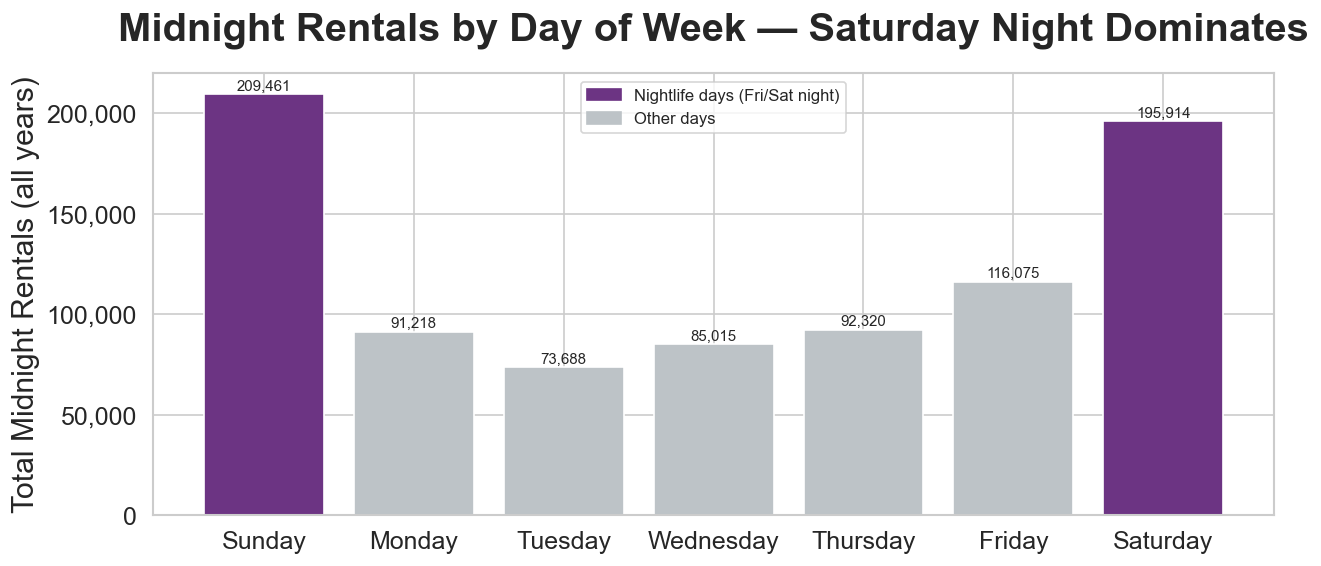

 day_name  midnight_rentals  twoam_rentals  avg_nighttime_min
   Sunday            209461         110484               32.2
   Monday             91218          29884               31.0
  Tuesday             73688          25079               28.3
Wednesday             85015          27362               32.5
 Thursday             92320          32515               30.1
   Friday            116075          41569               31.3
 Saturday            195914          99145               31.7


In [6]:
sql = """
SELECT
    CASE EXTRACT(DAYOFWEEK FROM start_date)
        WHEN 1 THEN 'Sunday'   WHEN 2 THEN 'Monday'
        WHEN 3 THEN 'Tuesday'  WHEN 4 THEN 'Wednesday'
        WHEN 5 THEN 'Thursday' WHEN 6 THEN 'Friday'
        WHEN 7 THEN 'Saturday' END AS day_name,
    EXTRACT(DAYOFWEEK FROM start_date) AS dow_num,
    SUM(CASE WHEN EXTRACT(HOUR FROM start_date) = 0 THEN 1 ELSE 0 END) AS midnight_rentals,
    SUM(CASE WHEN EXTRACT(HOUR FROM start_date) = 2 THEN 1 ELSE 0 END) AS twoam_rentals,
    ROUND(AVG(CASE WHEN EXTRACT(HOUR FROM start_date) BETWEEN 0 AND 4
              THEN duration_min END), 1) AS avg_nighttime_min
FROM `m2-dataset-study.london_bicycles_dev_facts.fact_rentals`
GROUP BY day_name, dow_num
ORDER BY dow_num
"""
df = bq(sql)

day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
df['day_name'] = pd.Categorical(df['day_name'], categories=day_order, ordered=True)
df = df.sort_values('day_name')

fig, ax = plt.subplots(figsize=(11, 5))
colours = ['#6C3483' if d in ['Saturday','Sunday'] else '#BDC3C7' for d in df['day_name']]
bars = ax.bar(df['day_name'], df['midnight_rentals'], color=colours)
ax.set_title('Midnight Rentals by Day of Week — Saturday Night Dominates',
             fontsize=24, fontweight='bold')
ax.set_ylabel('Total Midnight Rentals (all years)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{bar.get_height():,.0f}", ha='center', va='bottom', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#6C3483', label='Nightlife days (Fri/Sat night)'),
                   Patch(color='#BDC3C7', label='Other days')], fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/04_midnight_by_dow.png', bbox_inches='tight')
plt.show()
print(df[['day_name','midnight_rentals','twoam_rentals','avg_nighttime_min']].to_string(index=False))

## 4.2 — Top nightlife departure stations

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


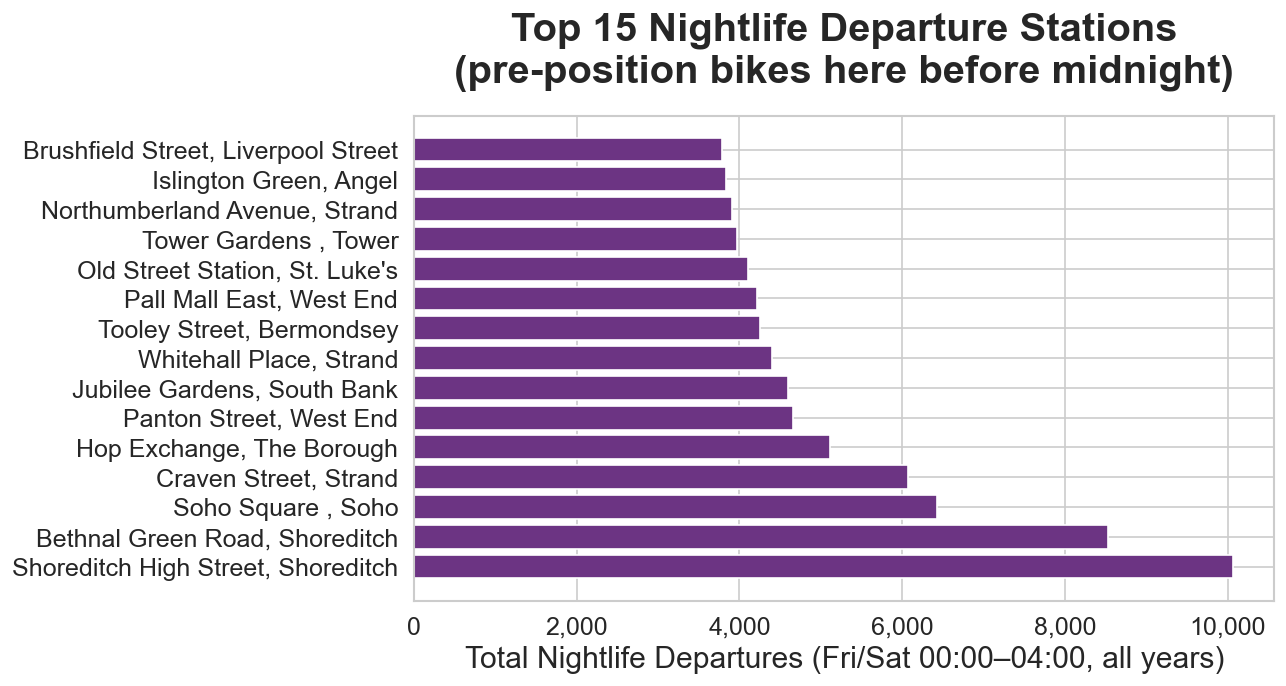

                       station_name  total_nightlife_departures  avg_duration_min
 Shoreditch High Street, Shoreditch                       10072              28.4
     Bethnal Green Road, Shoreditch                        8533              24.7
                 Soho Square , Soho                        6423              32.8
              Craven Street, Strand                        6077              34.8
          Hop Exchange, The Borough                        5107              34.3
            Panton Street, West End                        4659              30.6
        Jubilee Gardens, South Bank                        4591             150.4
            Whitehall Place, Strand                        4394              35.0
          Tooley Street, Bermondsey                        4251              49.0
           Pall Mall East, West End                        4216              42.2
     Old Street Station, St. Luke's                        4105              38.7
              To

In [11]:
sql2 = """
SELECT
    station_name,
    SUM(departures) AS total_nightlife_departures,
    ROUND(AVG(avg_duration_min), 1) AS avg_duration_min,
    latitude,
    longitude
FROM `m2-dataset-study.london_bicycles_dev_marts.mart_nightlife_demand`
WHERE station_name IS NOT NULL
GROUP BY station_name, latitude, longitude
ORDER BY total_nightlife_departures DESC
LIMIT 15
"""
top = bq(sql2)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top['station_name'], top['total_nightlife_departures'], color='#6C3483')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Total Nightlife Departures (Fri/Sat 00:00–04:00, all years)')
ax.set_title('Top 15 Nightlife Departure Stations\n(pre-position bikes here before midnight)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/04_nightlife_top_stations.png', bbox_inches='tight')
plt.show()
print(top[['station_name','total_nightlife_departures','avg_duration_min']].to_string(index=False))

## 4.3 — Nightlife vs fleet average duration comparison

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


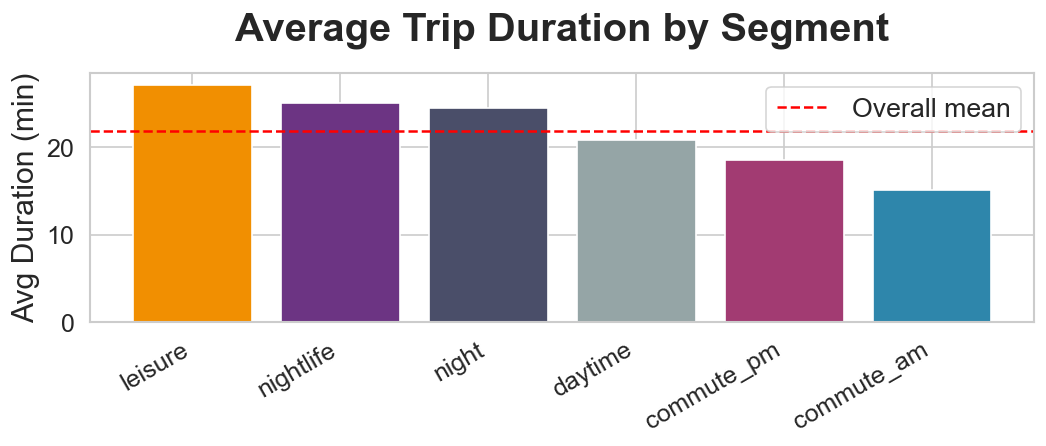

trip_segment  avg_min    trips
     leisure     27.1 16141235
   nightlife     25.0   832302
       night     24.5  1756682
     daytime     20.8 26879553
  commute_pm     18.5 21280963
  commute_am     15.1 16223140


In [12]:
dur_sql = """
SELECT
    trip_segment,
    ROUND(AVG(duration_min), 1) AS avg_min,
    COUNT(*) AS trips
FROM `m2-dataset-study.london_bicycles_dev_facts.fact_rentals`
WHERE NOT is_anomalous_duration
GROUP BY trip_segment
ORDER BY avg_min DESC
"""
dur = bq(dur_sql)

colours = {'nightlife': '#6C3483', 'leisure': '#F18F01', 'commute_am': '#2E86AB',
           'commute_pm': '#A23B72', 'daytime': '#95A5A6', 'night': '#4A4E69'}
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(dur['trip_segment'], dur['avg_min'],
       color=[colours.get(s, '#888') for s in dur['trip_segment']])
ax.axhline(dur['avg_min'].mean(), color='red', linestyle='--', label=f'Overall mean')
ax.set_ylabel('Avg Duration (min)')
ax.set_title('Average Trip Duration by Segment', fontsize=24, fontweight='bold')
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/04_duration_by_segment.png', bbox_inches='tight')
plt.show()
print(dur.to_string(index=False))